C:\Users\Fe\.conda\envs\ml_lab\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Fe\.conda\envs\ml_lab\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\Fe\.conda\envs\ml_lab\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Users\Fe\.conda\envs\ml_lab\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\Fe\.conda\envs\ml_lab\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
 

                Method  Accuracy
0      Without Scaling  0.912281
1  With StandardScaler  0.956140


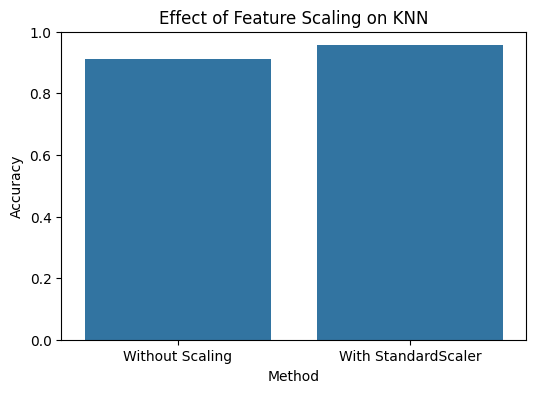

Cross-validation scores: [0.94505495 1.         0.94505495 0.97802198 0.96703297]
Mean CV accuracy: 0.9670329670329669
Standard deviation: 0.020850182374736577
Best parameters: {'knn__metric': 'euclidean', 'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
Best cross-validation score: 0.9714285714285715
Test accuracy: 0.9736842105263158
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



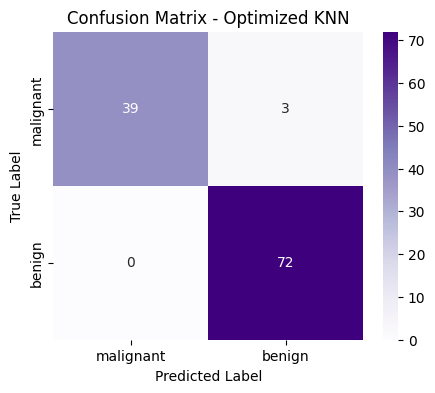

    param_knn__n_neighbors param_knn__weights param_knn__metric  \
5                        7           distance         euclidean   
4                        7            uniform         euclidean   
0                        3            uniform         euclidean   
1                        3           distance         euclidean   
6                        9            uniform         euclidean   
7                        9           distance         euclidean   
3                        5           distance         euclidean   
2                        5            uniform         euclidean   
11                       3           distance         manhattan   
10                       3            uniform         manhattan   

    mean_test_score  rank_test_score  
5          0.971429                1  
4          0.971429                1  
0          0.969231                3  
1          0.969231                3  
6          0.969231                3  
7          0.969231         

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

knn_without_scaling = KNeighborsClassifier(n_neighbors=5)
knn_without_scaling.fit(X_train, y_train)
y_pred_without_scaling = knn_without_scaling.predict(X_test)
accuracy_without_scaling = accuracy_score(y_test, y_pred_without_scaling)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
pipeline.fit(X_train, y_train)
y_pred_pipeline = pipeline.predict(X_test)
accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)

compare_scaling = pd.DataFrame({
    "Method": ["Without Scaling", "With StandardScaler"],
    "Accuracy": [accuracy_without_scaling, accuracy_pipeline]
})
print(compare_scaling)

plt.figure(figsize=(6, 4))
sns.barplot(data=compare_scaling, x="Method", y="Accuracy")
plt.title("Effect of Feature Scaling on KNN")
plt.ylim(0, 1)
plt.show()

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

param_grid = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best, target_names=cancer.target_names))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title("Confusion Matrix - Optimized KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

cv_results = pd.DataFrame(grid_search.cv_results_)
print(cv_results[[
    "param_knn__n_neighbors",
    "param_knn__weights",
    "param_knn__metric",
    "mean_test_score",
    "rank_test_score"
]].sort_values(by="rank_test_score").head(10))